# Proyek Klasifikasi Primata v2
Notebook ini telah dirapikan agar setiap tahapan berjalan secara modular, efisien, dan mudah dipantau.

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

# 1. Cek GPU
gpus = tf.config.list_physical_devices('GPU')
print("GPU Tersedia:", gpus)
if gpus:
    print(f"Menggunakan GPU: {gpus[0].name}")
else:
    print("GPU tidak terdeteksi. Pastikan runtime diatur ke GPU.")

# 2. Mount Google Drive dan Setup Folder
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/skripsi_primata/v2'
WORK = '/content/work'

os.makedirs(BASE, exist_ok=True)
os.makedirs(WORK, exist_ok=True)
print(f"Folder BASE (permanen): {BASE}")
print(f"Folder WORK (lokal cepat): {WORK}")

# 3. Instalasi Packages
!pip install -q transformers torch scikit-learn seaborn pandas requests tqdm pillow

# 4. Konstanta Global & Reproduksibilitas (Seed)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ["bekantan", "orangutan_kalimantan", "orangutan_sumatra"]
IMG_SIZE = (288, 288)
DET_MODEL = "google/owlv2-base-patch16-ensemble"
QUERIES = ["a monkey", "an orangutan", "an ape", "a primate"]
DET_THRESHOLD = 0.10
CROP_SCALE = 1.2

print("Setup selesai. Konstanta global dan seed telah berhasil dikonfigurasi.")

GPU Tersedia: []
GPU tidak terdeteksi. Pastikan runtime diatur ke GPU.
Mounted at /content/drive
Folder BASE (permanen): /content/drive/MyDrive/skripsi_primata/v2
Folder WORK (lokal cepat): /content/work
Setup selesai. Konstanta global dan seed telah berhasil dikonfigurasi.


## Langkah 2: Ekstraksi Dataset Mentah (Raw Dataset)
Tahap ini memulihkan arsip dataset mentah dari Google Drive ke penyimpanan lokal `/content/work`.

In [2]:
import os
import shutil
import pandas as pd

# Definisikan jalur folder sesuai konstanta setup
RAW_DIR = os.path.join(WORK, "dataset_raw")
MANIFEST_PATH = os.path.join(WORK, "manifest_raw.csv")
ZIP_SOURCE_PATH = os.path.join(BASE, "dataset_raw_archive.zip")

os.makedirs(WORK, exist_ok=True)

# Verifikasi apakah arsip dataset sebelumnya ada di Google Drive
if os.path.exists(ZIP_SOURCE_PATH):
    print(f"Menemukan arsip dataset di Google Drive: {ZIP_SOURCE_PATH}")
    print("Mengekstrak dataset ke folder kerja lokal WORK...")

    # Buat direktori sementara untuk ekstraksi
    tmp_extract_dir = os.path.join(WORK, "tmp_extract")
    os.makedirs(tmp_extract_dir, exist_ok=True)

    # Ekstrak arsip
    shutil.unpack_archive(ZIP_SOURCE_PATH, tmp_extract_dir, "zip")

    # Pindahkan dataset_raw ke WORK
    src_raw_folder = os.path.join(tmp_extract_dir, "dataset_raw")
    if os.path.exists(src_raw_folder):
        if os.path.exists(RAW_DIR):
            shutil.rmtree(RAW_DIR)
        shutil.move(src_raw_folder, RAW_DIR)
        print("Dataset raw berhasil diekstrak ke WORK.")

    # Pindahkan manifest_raw.csv ke WORK
    src_manifest_file = os.path.join(tmp_extract_dir, "manifest_raw.csv")
    if os.path.exists(src_manifest_file):
        shutil.copy2(src_manifest_file, MANIFEST_PATH)
        print("Manifest raw berhasil dipulihkan ke WORK.")

    # Bersihkan folder sementara
    shutil.rmtree(tmp_extract_dir)

else:
    print(f"Arsip {ZIP_SOURCE_PATH} tidak ditemukan di Google Drive.")
    print("Harap pastikan Anda telah menjalankan pengunduhan sebelumnya atau file zip tersebut berada di folder BASE.")

# Validasi hasil ekstraksi dengan memuat manifest
if os.path.exists(MANIFEST_PATH):
    df_manifest = pd.read_csv(MANIFEST_PATH)
    print("\n================ STATISTIK DATASET YANG DIPULIHKAN ================")
    print(f"Total foto di dalam manifest: {len(df_manifest)}")
    for cls in CLASS_NAMES:
        df_cls = df_manifest[df_manifest['kelas'] == cls]
        obs_unik = df_cls['observation_id'].nunique()
        foto_unik = df_cls['photo_id'].nunique()
        user_unik = df_cls['user_id'].nunique()
        print(f"Kelas: {cls}")
        print(f"  - Jumlah Observasi Unik : {obs_unik}")
        print(f"  - Jumlah Foto             : {foto_unik}")
        print(f"  - Jumlah Pengamat Unik    : {user_unik}")
else:
    print("Gagal memuat manifest. Silakan periksa kembali file arsip Anda di Google Drive.")

Menemukan arsip dataset di Google Drive: /content/drive/MyDrive/skripsi_primata/v2/dataset_raw_archive.zip
Mengekstrak dataset ke folder kerja lokal WORK...
Dataset raw berhasil diekstrak ke WORK.
Manifest raw berhasil dipulihkan ke WORK.

================ STATISTIK DATASET YANG DIPULIHKAN ================
Total foto di dalam manifest: 3000
Kelas: bekantan
  - Jumlah Observasi Unik : 722
  - Jumlah Foto             : 1000
  - Jumlah Pengamat Unik    : 408
Kelas: orangutan_kalimantan
  - Jumlah Observasi Unik : 705
  - Jumlah Foto             : 1000
  - Jumlah Pengamat Unik    : 392
Kelas: orangutan_sumatra
  - Jumlah Observasi Unik : 717
  - Jumlah Foto             : 1000
  - Jumlah Pengamat Unik    : 319


## Langkah 3: Pembagian Data (Data Splitting)
Tahap ini membagi data berdasarkan kelompok observasi (`user_id` & `observed_on`) untuk mencegah kebocoran data (*data leakage*).

In [3]:
import pandas as pd
import numpy as np
import os

# 1. Baca manifest_raw.csv dari WORK
manifest_raw_path = os.path.join(WORK, "manifest_raw.csv")
df = pd.read_csv(manifest_raw_path)

# 2. Buat kunci kelompok (group key)
# Kunci kelompok = user_id_observed_on (jika kosong/null pakai observation_id)
def get_group_key(row):
    user_id = str(row['user_id']).strip() if pd.notna(row['user_id']) else ""
    observed_on = str(row['observed_on']).strip() if pd.notna(row['observed_on']) else ""
    if user_id and observed_on:
        # Tambahkan prefix kelas untuk menjamin grup unik antar-kelas
        return f"{row['kelas']}_{user_id}_{observed_on}"
    else:
        return f"{row['kelas']}_obs_{row['observation_id']}"

df['group_key'] = df.apply(get_group_key, axis=1)

# Inisialisasi kolom split
df['split'] = 'unassigned'

# 3. Proses Pembagian Split per Kelas
np.random.seed(SEED)

for cls in CLASS_NAMES:
    df_cls = df[df['kelas'] == cls].copy()

    # Kumpulkan kelompok unik dan hitung jumlah foto per kelompok
    group_counts = df_cls['group_key'].value_counts().to_dict()
    groups = list(group_counts.keys())

    # Acak urutan kelompok dengan SEED
    np.random.shuffle(groups)

    total_photos = len(df_cls)
    target_train = int(total_photos * 0.70)
    target_val = int(total_photos * 0.15)
    target_test = total_photos - target_train - target_val

    train_groups = []
    val_groups = []
    test_groups = []

    train_count, val_count, test_count = 0, 0, 0

    # Distribusi Greedy
    for grp in groups:
        count = group_counts[grp]
        # Tentukan penempatan dengan prioritas mengisi yang paling jauh dari target relatifnya
        diff_train = max(0, target_train - train_count)
        diff_val = max(0, target_val - val_count)
        diff_test = max(0, target_test - test_count)

        max_diff = max(diff_train, diff_val, diff_test)

        if max_diff == diff_train and diff_train > 0:
            train_groups.append(grp)
            train_count += count
        elif max_diff == diff_val and diff_val > 0:
            val_groups.append(grp)
            val_count += count
        else:
            test_groups.append(grp)
            test_count += count

    # Petakan kembali kelompok ke DataFrame utama secara ketat berdasarkan kelas
    df.loc[(df['kelas'] == cls) & (df['group_key'].isin(train_groups)), 'split'] = 'train'
    df.loc[(df['kelas'] == cls) & (df['group_key'].isin(val_groups)), 'split'] = 'val'
    df.loc[(df['kelas'] == cls) & (df['group_key'].isin(test_groups)), 'split'] = 'test'

# 4. Simpan manifest baru dengan split ke BASE di Google Drive
manifest_split_path = os.path.join(BASE, "manifest_split.csv")
df.to_csv(manifest_split_path, index=False)
print(f"Manifest split berhasil disimpan ke: {manifest_split_path}\n")

# 5. Verifikasi Kebocoran Data (Assert)
train_df = df[df['split'] == 'train']
val_df = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']

train_groups_set = set(train_df['group_key'])
val_groups_set = set(val_df['group_key'])
test_groups_set = set(test_df['group_key'])

train_obs_set = set(train_df['observation_id'])
val_obs_set = set(val_df['observation_id'])
test_obs_set = set(test_df['observation_id'])

train_md5_set = set(train_df['md5'])
val_md5_set = set(val_df['md5'])
test_md5_set = set(test_df['md5'])

# Pastikan tidak ada irisan kelompok, observasi, atau MD5 antar split
assert train_groups_set.isdisjoint(val_groups_set), "Kebocoran terdeteksi: group_key tumpang tindih antara train dan val!"
assert train_groups_set.isdisjoint(test_groups_set), "Kebocoran terdeteksi: group_key tumpang tindih antara train dan test!"
assert val_groups_set.isdisjoint(test_groups_set), "Kebocoran terdeteksi: group_key tumpang tindih antara val dan test!"

assert train_obs_set.isdisjoint(val_obs_set), "Kebocoran terdeteksi: observation_id tumpang tindih antara train dan val!"
assert train_obs_set.isdisjoint(test_obs_set), "Kebocoran terdeteksi: observation_id tumpang tindih antara train dan test!"
assert val_obs_set.isdisjoint(test_obs_set), "Kebocoran terdeteksi: observation_id tumpang tindih antara val dan test!"

assert train_md5_set.isdisjoint(val_md5_set), "Kebocoran terdeteksi: md5 tumpang tindih antara train dan val!"
assert train_md5_set.isdisjoint(test_md5_set), "Kebocoran terdeteksi: md5 tumpang tindih antara train dan test!"
assert val_md5_set.isdisjoint(test_md5_set), "Kebocoran terdeteksi: md5 tumpang tindih antara val dan test!"

print("Verifikasi Berhasil: Tidak ada kebocoran group_key, observation_id, maupun md5 antar-split!\n")

# 6. Cetak Tabel Distribusi Jumlah Foto dan Jumlah Kelompok
summary_data = []
for cls in CLASS_NAMES:
    for spl in ['train', 'val', 'test']:
        sub_df = df[(df['kelas'] == cls) & (df['split'] == spl)]
        num_photos = len(sub_df)
        num_groups = sub_df['group_key'].nunique()
        summary_data.append({
            'Kelas': cls,
            'Split': spl,
            'Jumlah Foto': num_photos,
            'Jumlah Kelompok': num_groups
        })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

Manifest split berhasil disimpan ke: /content/drive/MyDrive/skripsi_primata/v2/manifest_split.csv

Verifikasi Berhasil: Tidak ada kebocoran group_key, observation_id, maupun md5 antar-split!



,Kelas,Split,Jumlah Foto,Jumlah Kelompok
0,bekantan,train,701,352
1,bekantan,val,150,84
2,bekantan,test,149,89
3,orangutan_kalimantan,train,698,382
4,orangutan_kalimantan,val,148,60
5,orangutan_kalimantan,test,154,87
6,orangutan_sumatra,train,698,352
7,orangutan_sumatra,val,153,80
8,orangutan_sumatra,test,149,91


## Langkah 4: Deteksi Objek & Pemotongan (OWLv2 Object Detection & Cropping)
Tahap ini mendeteksi keberadaan primata menggunakan model OWLv2, melakukan crop otomatis dengan skala yang ditentukan, dan menyimpan hasilnya.

In [3]:
import os
import shutil

CROP_ZIP_PATH = os.path.join(BASE, "dataset_crop_archive.zip")
CROP_DIR_WORK = os.path.join(WORK, "dataset_crop")
DET_CSV_DRIVE = os.path.join(BASE, "deteksi_hewan.csv")
DET_CSV_WORK = os.path.join(WORK, "deteksi_hewan.csv")

# 1. Pulihkan Gambar Terpotong (Cropped Images)
if os.path.exists(CROP_ZIP_PATH):
    print(f"Menemukan arsip gambar hasil crop di Drive: {CROP_ZIP_PATH}")
    if os.path.exists(CROP_DIR_WORK):
        shutil.rmtree(CROP_DIR_WORK)
    os.makedirs(CROP_DIR_WORK, exist_ok=True)

    print("Mengekstrak cropped dataset ke lokal WORK (Sangat Cepat)...")
    shutil.unpack_archive(CROP_ZIP_PATH, CROP_DIR_WORK, "zip")
    print("Berhasil memulihkan dataset_crop ke WORK lokal!")
else:
    print("Arsip hasil crop tidak ditemukan di Drive. Pastikan Anda telah menyelesaikan Langkah 4 setidaknya satu kali.")

# 2. Pulihkan File CSV Metadata Deteksi
if os.path.exists(DET_CSV_DRIVE):
    shutil.copy2(DET_CSV_DRIVE, DET_CSV_WORK)
    print(f"Berhasil memulihkan metadata deteksi_hewan.csv ke WORK: {DET_CSV_WORK}")
else:
    print("File deteksi_hewan.csv belum ada di Google Drive.")

Menemukan arsip gambar hasil crop di Drive: /content/drive/MyDrive/skripsi_primata/v2/dataset_crop_archive.zip
Mengekstrak cropped dataset ke lokal WORK (Sangat Cepat)...
Berhasil memulihkan dataset_crop ke WORK lokal!
Berhasil memulihkan metadata deteksi_hewan.csv ke WORK: /content/work/deteksi_hewan.csv


Memuat model OWLv2 (google/owlv2-base-patch16-ensemble) pada perangkat: cuda...


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/418 [00:00<?, ?it/s]

Melanjutkan deteksi yang sudah ada...
Mulai menjalankan deteksi OWLv2 dan cropping...


Deteksi & Crop:   0%|          | 0/3000 [00:00<?, ?it/s]

Pemrosesan deteksi OWLv2 dan cropping selesai!

================ PERSENTASE FALLBACK ================
kelas                 split
bekantan              test     0.67
                      train    1.14
                      val      0.00
orangutan_kalimantan  test     1.95
                      train    1.58
                      val      0.00
orangutan_sumatra     test     0.67
                      train    1.43
                      val      1.96 %

Menampilkan Contact Sheet: 30 Gambar Acak


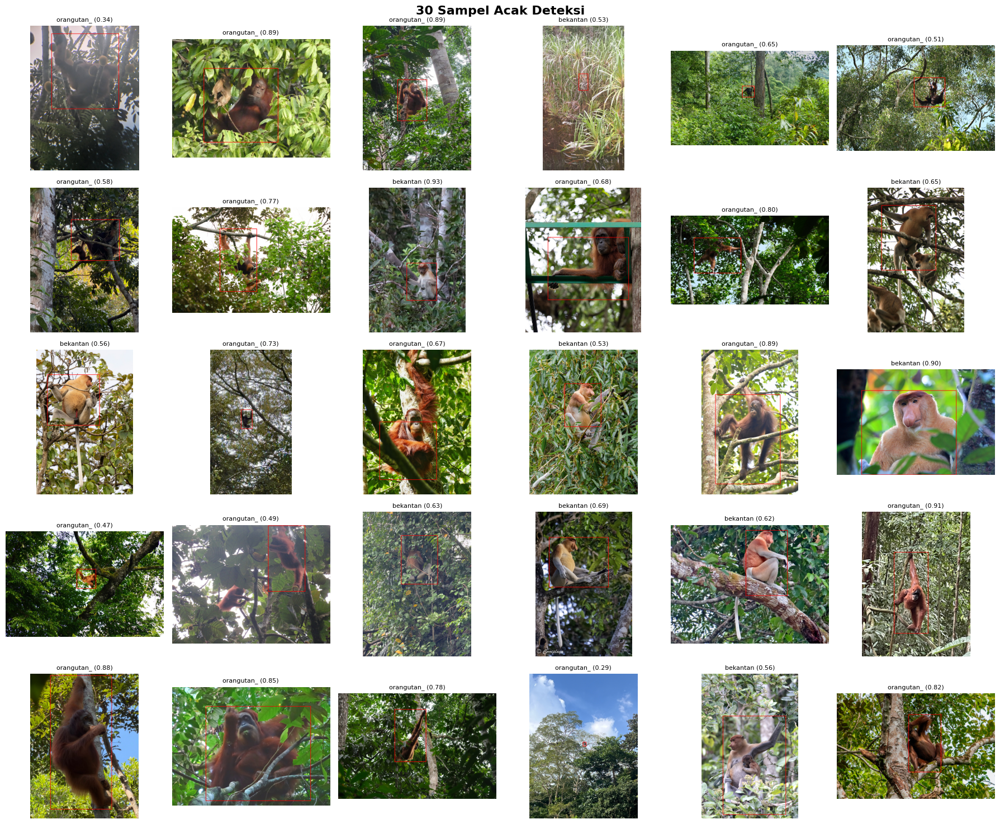


Menampilkan Contact Sheet: 30 Gambar dengan Skor Deteksi Terendah (Bukan Fallback)


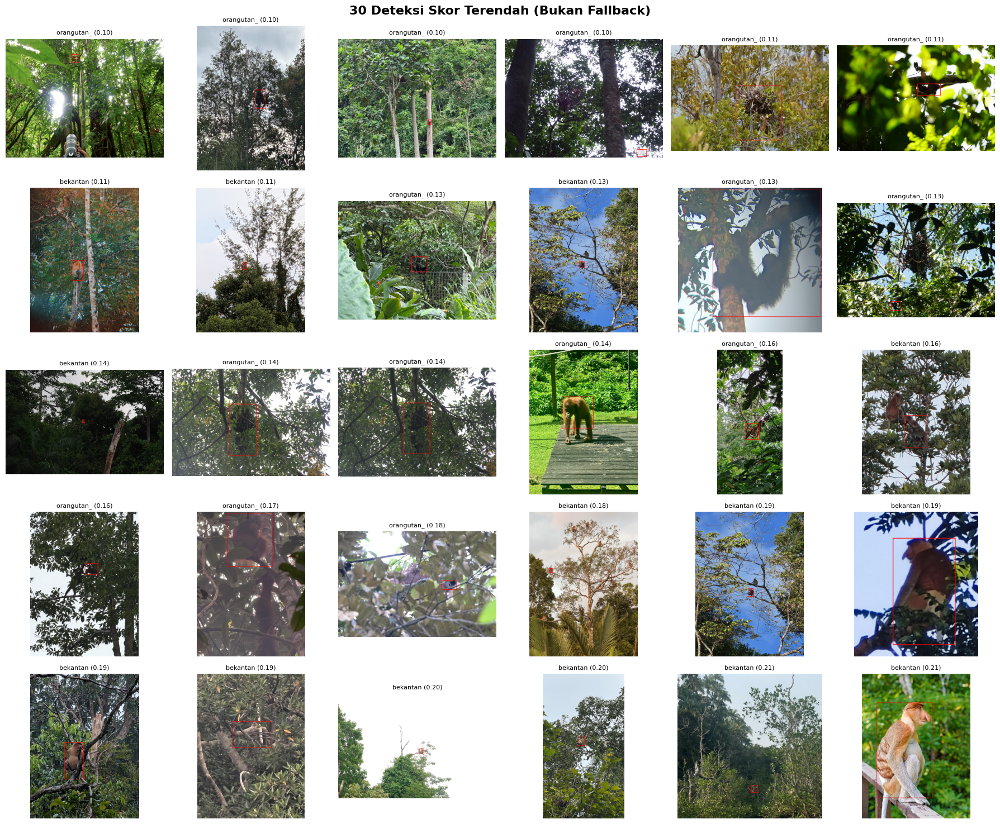


Menampilkan Contact Sheet: 30 Gambar Fallback (Deteksi gagal)


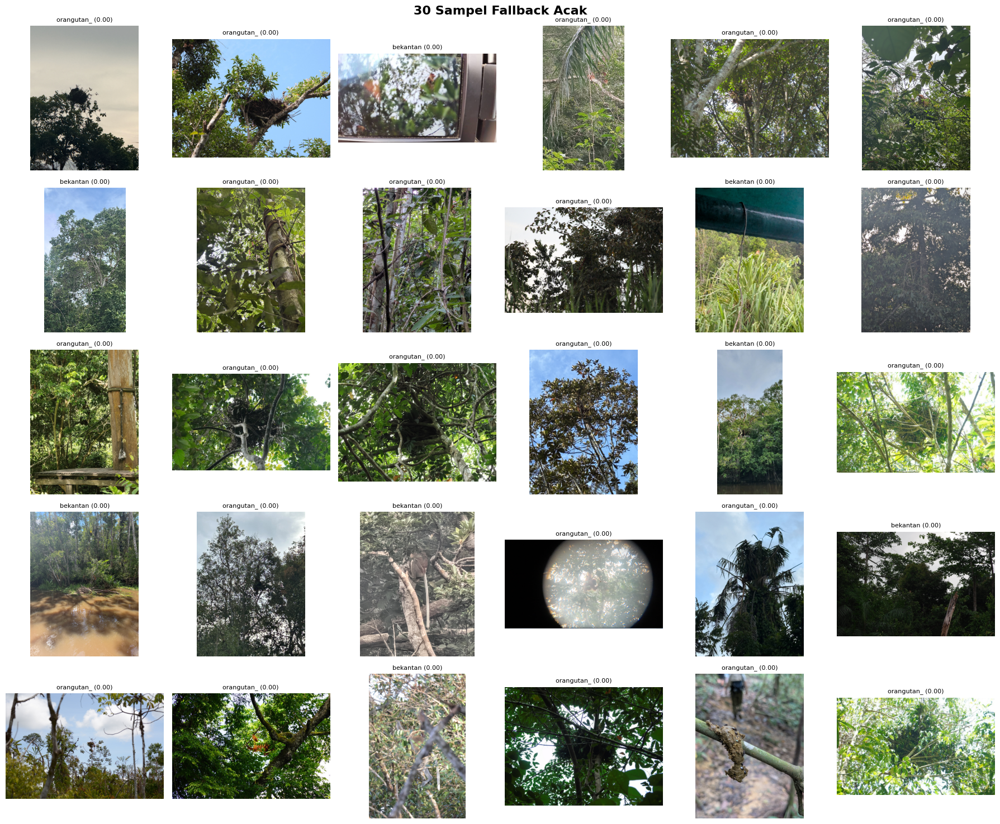


Mengompresi hasil deteksi ke folder BASE...
Kompresi dan pencadangan selesai! Berkas tersedia di folder BASE.


In [5]:
import os
import torch
import pandas as pd
import numpy as np
import shutil
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# 1. Load Model OWLv2 dengan FP16 (jika menggunakan GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Memuat model OWLv2 ({DET_MODEL}) pada perangkat: {device}...")
det_processor = AutoProcessor.from_pretrained(DET_MODEL)
det_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    DET_MODEL,
    torch_dtype=torch_dtype
).to(device)
det_model.eval()

# 2. Definisikan Folder-Folder
manifest_split_path = os.path.join(BASE, "manifest_split.csv")
if not os.path.exists(manifest_split_path):
    raise FileNotFoundError(f"Manifest split tidak ditemukan di {manifest_split_path}. Silakan jalankan cell split data terlebih dahulu.")

df_split = pd.read_csv(manifest_split_path)

CROP_DIR = os.path.join(WORK, "dataset_crop")
FULL_DIR = os.path.join(WORK, "dataset_full")
DET_CSV_PATH = os.path.join(WORK, "deteksi_hewan.csv")

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(CROP_DIR, split, cls), exist_ok=True)
        os.makedirs(os.path.join(FULL_DIR, split, cls), exist_ok=True)

# Ambil state jika sudah ada sebelumnya (resume)
if os.path.exists(DET_CSV_PATH):
    print("Melanjutkan deteksi yang sudah ada...")
    df_det = pd.read_csv(DET_CSV_PATH)
    processed_files = set(df_det['file'].tolist())
    det_records = df_det.to_dict('records')
else:
    processed_files = set()
    det_records = []

# 3. Proses Deteksi dan Pemotongan
print("Mulai menjalankan deteksi OWLv2 dan cropping...")
missing_files_count = 0

for idx, row in tqdm(df_split.iterrows(), total=len(df_split), desc="Deteksi & Crop"):
    rel_file = row['file'] # format: dataset_raw/<kelas>/<file_name>
    split = row['split']
    cls = row['kelas']

    if rel_file in processed_files:
        continue

    # Jalur file asli
    src_path = os.path.join(WORK, rel_file)
    file_name = os.path.basename(rel_file)

    # Verifikasi keberadaan file fisik di WORK sebelum diproses
    if not os.path.exists(src_path):
        missing_files_count += 1
        if missing_files_count <= 5:
            print(f"Peringatan: File tidak ditemukan di WORK: {src_path}. Pastikan ekstraksi di Cell 2 selesai sempurna.")
        elif missing_files_count == 6:
            print("Peringatan serupa disembunyikan untuk menghemat log...")
        continue

    # Jalur simpan
    crop_dest_path = os.path.join(CROP_DIR, split, cls, file_name)
    full_dest_path = os.path.join(FULL_DIR, split, cls, file_name)

    # Selalu salin gambar asli ke dataset_full
    shutil.copy2(src_path, full_dest_path)

    try:
        img = Image.open(src_path).convert("RGB")
        W, H = img.size
    except Exception as e:
        print(f"File rusak: {src_path}. Dilewati.")
        continue

    # Jalankan OWLv2
    inputs = det_processor(text=[QUERIES], images=img, return_tensors="pt").to(device)
    if device == "cuda":
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor) and v.dtype == torch.float32:
                inputs[k] = v.to(torch.float16)

    with torch.no_grad():
        outputs = det_model(**inputs)

    # Post-processing menggunakan modul image_processor internal dari processor
    target_sizes = torch.tensor([[max(H, W), max(H, W)]]).to(device)
    results = det_processor.image_processor.post_process_object_detection(
        outputs, threshold=DET_THRESHOLD, target_sizes=target_sizes
    )[0]

    boxes = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()

    best_score = 0.0
    best_box = None
    fallback = 1

    if len(scores) > 0:
        # Cari box dengan skor tertinggi
        best_idx = np.argmax(scores)
        best_score = float(scores[best_idx])

        # Ambil koordinat box (dalam koordinat OWLv2 yang dipad ke square max(H,W))
        x1, y1, x2, y2 = boxes[best_idx]

        # Clamp box ke ukuran real gambar asli
        x1 = max(0, min(x1, W))
        y1 = max(0, min(y1, H))
        x2 = max(0, min(x2, W))
        y2 = max(0, min(y2, H))

        w = x2 - x1
        h = y2 - y1

        # Hanya gunakan jika ukuran box valid
        if w > 0 and h > 0:
            best_box = (x1, y1, x2, y2)

    if best_box is not None:
        x1, y1, x2, y2 = best_box
        w = x2 - x1
        h = y2 - y1
        cx = x1 + w/2
        cy = y1 + h/2

        # Rumus crop sesuai kontrak
        sisi = max(w, h) * CROP_SCALE
        sisi = max(1, min(sisi, W, H))
        sx = min(max(cx - sisi/2, 0), W - sisi)
        sy = min(max(cy - sisi/2, 0), H - sisi)

        crop_coords = (round(sx), round(sy), round(sx+sisi), round(sy+sisi))
        crop_width = crop_coords[2] - crop_coords[0]
        crop_height = crop_coords[3] - crop_coords[1]

        # Cek syarat minimum crop
        if crop_width >= 8 and crop_height >= 8:
            try:
                cropped_img = img.crop(crop_coords)
                # Simpan dengan kualitas 95
                cropped_img.save(crop_dest_path, "JPEG", quality=95)
                fallback = 0
            except Exception:
                fallback = 1

    if fallback == 1:
        # Salin gambar asli jika tidak ada deteksi atau crop tidak valid
        shutil.copy2(src_path, crop_dest_path)
        x1, y1, x2, y2 = 0, 0, W, H
        best_score = 0.0

    # Hitung luas relatif terhadap luas gambar asli
    luas_rel = ((x2 - x1) * (y2 - y1)) / (W * H)

    det_records.append({
        'file': rel_file,
        'split': split,
        'kelas': cls,
        'skor_deteksi': best_score,
        'x1': float(x1),
        'y1': float(y1),
        'x2': float(x2),
        'y2': float(y2),
        'luas_rel': float(luas_rel),
        'fallback': fallback
    })

    # Simpan progress berkala
    if idx % 50 == 0 or idx == len(df_split) - 1:
        if len(det_records) > 0:
            pd.DataFrame(det_records).to_csv(DET_CSV_PATH, index=False)

if missing_files_count > 0:
    print(f"\nPERINGATAN: Sebanyak {missing_files_count} file gambar dilewati karena tidak ditemukan fisik filenya di folder WORK.")

if len(det_records) == 0:
    print("Tidak ada data deteksi baru yang diproses. Silakan pastikan file gambar di folder WORK/dataset_raw sudah terekstrak sempurna.")
else:
    df_det = pd.DataFrame(det_records)
    df_det.to_csv(DET_CSV_PATH, index=False)
    print("Pemrosesan deteksi OWLv2 dan cropping selesai!")

    # 4. Hitung Persentase Fallback
    print("\n================ PERSENTASE FALLBACK ================")
    fallback_summary = df_det.groupby(['kelas', 'split'])['fallback'].mean() * 100
    print(fallback_summary.round(2).to_string() + " %")

    # 5. Fungsi Visualisasi Contact Sheet
    def plot_contact_sheet(sub_df, title):
        fig, axes = plt.subplots(5, 6, figsize=(18, 15))
        axes = axes.flatten()

        # Ambil sampel
        sample_df = sub_df.head(30)

        for i, (_, r) in enumerate(sample_df.iterrows()):
            ax = axes[i]
            src_path = os.path.join(WORK, r['file'])
            try:
                img = Image.open(src_path).convert("RGB")
                draw = ImageDraw.Draw(img)
                if r['fallback'] == 0:
                    draw.rectangle([r['x1'], r['y1'], r['x2'], r['y2']], outline="red", width=3)
                ax.imshow(img)
                ax.set_title(f"{r['kelas'][:10]} ({r['skor_deteksi']:.2f})", fontsize=8)
            except Exception:
                ax.text(0.5, 0.5, "Error / Missing", ha='center', va='center')
            ax.axis('off')

        # Bersihkan sisa subplot jika data kurang dari 30
        for j in range(len(sample_df), 30):
            axes[j].axis('off')

        plt.suptitle(title, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Acak dataframe untuk visualisasi sampel acak
    df_det_shuffled = df_det.sample(frac=1.0, random_state=SEED)

    # Visualisasi 1: 30 Gambar Acak
    print("\nMenampilkan Contact Sheet: 30 Gambar Acak")
    plot_contact_sheet(df_det_shuffled, "30 Sampel Acak Deteksi")

    # Visualisasi 2: 30 Skor Terendah (Bukan Fallback)
    df_non_fallback = df_det[df_det['fallback'] == 0].sort_values(by='skor_deteksi', ascending=True)
    if len(df_non_fallback) > 0:
        print("\nMenampilkan Contact Sheet: 30 Gambar dengan Skor Deteksi Terendah (Bukan Fallback)")
        plot_contact_sheet(df_non_fallback, "30 Deteksi Skor Terendah (Bukan Fallback)")

    # Visualisasi 3: 30 Gambar Fallback Acak
    df_fallback = df_det[df_det['fallback'] == 1]
    if len(df_fallback) > 0:
        df_fallback_shuffled = df_fallback.sample(frac=1.0, random_state=SEED, replace=True if len(df_fallback) < 30 else False)
        print("\nMenampilkan Contact Sheet: 30 Gambar Fallback (Deteksi gagal)")
        plot_contact_sheet(df_fallback_shuffled, "30 Sampel Fallback Acak")

    # 6. Kompresi dan salin hasil ke BASE
    print("\nMengompresi hasil deteksi ke folder BASE...")
    shutil.make_archive(os.path.join(BASE, "dataset_crop_archive"), 'zip', CROP_DIR)
    shutil.make_archive(os.path.join(BASE, "dataset_full_archive"), 'zip', FULL_DIR)
    shutil.copy2(DET_CSV_PATH, os.path.join(BASE, "deteksi_hewan.csv"))
    print("Kompresi dan pencadangan selesai! Berkas tersedia di folder BASE.")

## Langkah 5: Definisi Pipeline Pelatihan & Dataset Loader
Membuat fungsi pembentuk tf.data.Dataset dengan optimasi `cache` dan `prefetch` serta utilitas augmentasi gambar.

In [5]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

def build_datasets(data_dir, seed=SEED):
    train_dir = os.path.join(data_dir, "train")
    val_dir = os.path.join(data_dir, "val")
    test_dir = os.path.join(data_dir, "test")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=True,
        seed=seed
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=False,
        seed=seed
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=False,
        seed=seed
    )
    return train_ds, val_ds, test_ds

def get_augmentation_layer(aug_level):
    if aug_level == "medium":
        r, z = 0.08, 0.15
    elif aug_level == "strong":
        r, z = 0.12, 0.25
    else:
        raise ValueError(f"Augmentasi level tidak valid: {aug_level}")

    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(r),
        layers.RandomZoom(z),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(0.15)
    ], name=f"augmentation_{aug_level}")

## Langkah 6: Arsitektur Model & Alur Latih (Training Pipeline)
Fungsi terpisah untuk melatih model dengan strategi dua tahap: *Feature Extraction* lalu *Fine-Tuning*.

In [4]:
def train_pipeline(data_dir, lr2, aug_level, seed=SEED, ep1=5, ep2=20):
    tf.random.set_seed(seed)
    train_ds, val_ds, test_ds = build_datasets(data_dir, seed=seed)
    aug_layer = get_augmentation_layer(aug_level)

    # Optimasi Pipeline
    train_ds = train_ds.cache().map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    # Membangun Model
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)
    clf = models.Model(inputs, outputs)

    loss_fn = losses.CategoricalCrossentropy(label_smoothing=0.1)

    # TAHAP 1: Pembekuan backbone
    base_model.trainable = False
    clf.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=loss_fn, metrics=["accuracy"])
    print(f"\n--- Tahap 1: Melatih Kepala Klasifikasi ({ep1} Epoch) ---")
    hist1 = clf.fit(train_ds, validation_data=val_ds, epochs=ep1, verbose=1)

    # TAHAP 2: Fine-Tuning
    print(f"\n--- Tahap 2: Fine-Tuning Backbone ({ep2} Epoch) ---")
    base_model.trainable = True
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    total_steps = steps_per_epoch * ep2
    lr_schedule = optimizers.schedules.CosineDecay(initial_learning_rate=lr2, decay_steps=total_steps)

    clf.compile(optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4), loss=loss_fn, metrics=["accuracy"])
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True)]

    hist2 = clf.fit(train_ds, validation_data=val_ds, epochs=ep2, callbacks=callbacks, verbose=1)
    val_loss, val_acc = clf.evaluate(val_ds, verbose=0)

    return clf, hist1, hist2, val_acc, val_loss

In [ ]:
import os
import json
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# 1. Fungsi Pembentuk Dataset
def build_datasets(data_dir, seed=SEED):
    # Muat train, val, dan test dari folder split lokal menggunakan image_dataset_from_directory
    train_dir = os.path.join(data_dir, "train")
    val_dir = os.path.join(data_dir, "val")
    test_dir = os.path.join(data_dir, "test")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=True,
        seed=seed
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=False,
        seed=seed
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        label_mode="categorical",
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=32,
        shuffle=False,
        seed=seed
    )
    return train_ds, val_ds, test_ds

# 2. Fungsi Builder Augmentasi
def get_augmentation_layer(aug_level):
    if aug_level == "medium":
        r, z = 0.08, 0.15
    elif aug_level == "strong":
        r, z = 0.12, 0.25
    else:
        raise ValueError(f"Augmentasi level tidak valid: {aug_level}")

    return models.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(r),
        layers.RandomZoom(z),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.15),
        layers.RandomBrightness(0.15)
    ], name=f"augmentation_{aug_level}")

# 3. Model Builder & Pipeline Training
def train_pipeline(data_dir, lr2, aug_level, seed=SEED, ep1=5, ep2=20):
    # Set seed untuk reproduksibilitas model
    tf.random.set_seed(seed)

    # Membangun dataset
    train_ds, val_ds, test_ds = build_datasets(data_dir, seed=seed)

    # Dapatkan layer augmentasi sesuai tingkat
    aug_layer = get_augmentation_layer(aug_level)

    # Optimasi Pipeline sesuai urutan wajib: cache -> map augment -> prefetch
    train_ds = train_ds.cache().map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    # Membangun model
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    # EfficientNetB0 menerima input 0-255 tanpa preprocess_input tambahan
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)
    clf = models.Model(inputs, outputs)

    # Loss function dengan label smoothing
    loss_fn = losses.CategoricalCrossentropy(label_smoothing=0.1)

    # TAHAP 1: Pembekuan backbone (Feature Extraction)
    base_model.trainable = False
    clf.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss=loss_fn,
        metrics=["accuracy"]
    )
    print(f"\n--- Tahap 1: Melatih kepala klasifikasi ({ep1} Epoch) ---")
    hist1 = clf.fit(train_ds, validation_data=val_ds, epochs=ep1, verbose=1)

    # TAHAP 2: Fine-Tuning dengan AdamW & CosineDecay
    print(f"\n--- Tahap 2: Fine-Tuning Backbone ({ep2} Epoch) ---")
    base_model.trainable = True

    # Pastikan seluruh layer BatchNormalization tetap beku agar statistik mean/variance tidak rusak
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # Hitung total langkah training
    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    total_steps = steps_per_epoch * ep2

    lr_schedule = optimizers.schedules.CosineDecay(
        initial_learning_rate=lr2,
        decay_steps=total_steps
    )

    clf.compile(
        optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss=loss_fn,
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=8,
            restore_best_weights=True
        )
    ]

    hist2 = clf.fit(
        train_ds,
        validation_data=val_ds,
        epochs=ep2,
        callbacks=callbacks,
        verbose=1
    )

    # Ambil metrik validasi terbaik dari epoch terbaik hasil pemulihan restore_best_weights
    val_loss, val_acc = clf.evaluate(val_ds, verbose=0)
    return clf, hist1, hist2, val_acc, val_loss

# 4. Menjalankan Grid Search Pencarian Konfigurasi Terpilih
configs = [
    {"name": "A", "lr2": 1e-4, "aug_level": "medium"},
    {"name": "B", "lr2": 5e-5, "aug_level": "medium"},
    {"name": "C", "lr2": 1e-4, "aug_level": "strong"}
]

grid_results = []
best_config = None
best_val_acc = -1.0
best_val_loss = float("inf")

CROP_DATASET_DIR = os.path.join(WORK, "dataset_crop")

print("Memulai Grid Search Konfigurasi...")
for cfg in configs:
    print(f"\n================ MENCOBA KONFIGURASI {cfg['name']} (lr2={cfg['lr2']}, aug_level={cfg['aug_level']}) ================")
    clf, h1, h2, val_acc, val_loss = train_pipeline(
        data_dir=CROP_DATASET_DIR,
        lr2=cfg['lr2'],
        aug_level=cfg['aug_level'],
        seed=SEED,
        ep1=5,
        ep2=20
    )

    grid_results.append({
        "Konfigurasi": cfg['name'],
        "Learning Rate 2": cfg['lr2'],
        "Augmentation Level": cfg['aug_level'],
        "Validation Accuracy": val_acc,
        "Validation Loss": val_loss
    })

    # Evaluasi pemilihan model terbaik (Tie-breaker: loss terkecil)
    is_better = False
    if val_acc > best_val_acc:
        is_better = True
    elif val_acc == best_val_acc:
        if val_loss < best_val_loss:
            is_better = True

    if is_better:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_config = cfg

# 5. Menampilkan Hasil Pencarian & Menyimpan Hasil
print("\n================ TABEL HASIL GRID SEARCH ================")
df_results = pd.DataFrame(grid_results)
display(df_results)

print(f"\nKonfigurasi terpilih adalah: {best_config['name']} dengan Akurasi Validasi: {best_val_acc:.4f}")

# Simpan ke BASE di Google Drive
config_save_path = os.path.join(BASE, "config_terpilih.json")
with open(config_save_path, "w") as f:
    json.dump(best_config, f, indent=4)

print(f"Konfigurasi terpilih berhasil disimpan di Google Drive: {config_save_path}")

Memulai Grid Search Konfigurasi...

================ MENCOBA KONFIGURASI A (lr2=0.0001, aug_level=medium) ================
Found 2097 files belonging to 3 classes.
Found 451 files belonging to 3 classes.
Found 452 files belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- Tahap 1: Melatih kepala klasifikasi (5 Epoch) ---
Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.6857 - loss: 0.7615 - val_accuracy: 0.8226 - val_loss: 0.5841
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 765ms/step - accuracy: 0.8155 - loss: 0.5955 - val_accuracy: 0.8359 - val_loss: 0.5557
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 54s 800ms/step - accuracy: 0.8340 - loss: 0.5713 - val_accuracy: 0.8315 - val_loss: 0.5446
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 80s 776ms/step - accuracy: 0.8460 - loss: 0.5507 - val_accuracy: 0.8581 - val_loss: 0.5356
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 84s 805ms/step - accuracy: 0.8646 - loss: 0.5405 - val_accuracy: 0.8625 - val_loss: 0.5271

--- Tahap 2

## Langkah 7: Pengaturan & Pembantu Evaluasi (Evaluation Helper)
Fungsi pembantu untuk memprediksi hasil evaluasi model secara standar dan menggunakan *Test-Time Augmentation* (TTA).

In [8]:
def evaluate_predictions(model, dataset):
    all_preds = []
    all_tta_preds = []
    all_labels = []
    all_confidences = []

    for images, labels in dataset:
        preds = model(images, training=False)
        all_preds.append(preds.numpy())
        all_confidences.append(np.max(preds.numpy(), axis=1))
        all_labels.append(labels.numpy())

        flipped_images = tf.image.flip_left_right(images)
        tta_preds = model(flipped_images, training=False)
        avg_preds = (preds + tta_preds) / 2.0
        all_tta_preds.append(avg_preds.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_tta_preds = np.concatenate(all_tta_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_confidences = np.concatenate(all_confidences, axis=0)

    pred_classes = np.argmax(all_preds, axis=1)
    tta_classes = np.argmax(all_tta_preds, axis=1)
    true_classes = np.argmax(all_labels, axis=1)

    return pred_classes, tta_classes, true_classes, all_confidences, all_preds

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. BACA CONFIG TERPILIH & SETUP
# ==========================================
config_path = os.path.join(BASE, "config_terpilih.json")
with open(config_path, "r") as f:
    best_cfg = json.load(f)

print(f"Konfigurasi terpilih yang dimuat: {best_cfg}")
lr2 = best_cfg["lr2"]
aug_level = best_cfg["aug_level"]

# Guna menghindari limit Colab Gratis, kita bisa latih 1 Seed utama dulu (misal: 42)
# Jika ingin melatih semua, checkpoint akan mengamankan proses Anda.
SEEDS_CROP = [42, 43, 44]
SEEDS_FULL = [42]

CROP_DIR = os.path.join(WORK, "dataset_crop")
FULL_DIR = os.path.join(WORK, "dataset_full")
DET_CSV_PATH = os.path.join(WORK, "deteksi_hewan.csv")

# Modifikasi train_pipeline untuk mendukung auto-checkpoint ke Google Drive
def train_pipeline_with_checkpoint(data_dir, lr2, aug_level, seed, prefix="crop", ep1=5, ep2=20):
    tf.random.set_seed(seed)
    train_ds, val_ds, test_ds = build_datasets(data_dir, seed=seed)
    aug_layer = get_augmentation_layer(aug_level)

    train_ds = train_ds.cache().map(lambda x, y: (aug_layer(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)
    clf = models.Model(inputs, outputs)

    loss_fn = losses.CategoricalCrossentropy(label_smoothing=0.1)

    # Tahap 1
    base_model.trainable = False
    clf.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=loss_fn, metrics=["accuracy"])
    print(f"\n--- [Seed {seed}] Tahap 1: Kepala Klasifikasi ({ep1} Epoch) ---")
    hist1 = clf.fit(train_ds, validation_data=val_ds, epochs=ep1, verbose=1)

    # Tahap 2 dengan Checkpoint berkala ke Google Drive (BASE)
    print(f"\n--- [Seed {seed}] Tahap 2: Fine-Tuning ({ep2} Epoch) ---")
    base_model.trainable = True
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    total_steps = steps_per_epoch * ep2
    lr_schedule = optimizers.schedules.CosineDecay(initial_learning_rate=lr2, decay_steps=total_steps)

    clf.compile(optimizer=optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4), loss=loss_fn, metrics=["accuracy"])

    # PATH CHECKPOINT DI DRIVE PERMANEN
    checkpoint_path = os.path.join(BASE, f"checkpoint_{prefix}_seed_{seed}.keras")

    # Jika putus di tengah jalan, model otomatis melanjutkan dari bobot terbaik yang tersimpan
    if os.path.exists(checkpoint_path):
        print(f"Menemukan checkpoint sebelumnya di {checkpoint_path}. Memuat bobot untuk melanjutkan...")
        clf.load_weights(checkpoint_path)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        # Callback untuk simpan progres setiap epoch ke Google Drive secara otomatis
        tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1)
    ]

    hist2 = clf.fit(train_ds, validation_data=val_ds, epochs=ep2, callbacks=callbacks, verbose=1)
    val_loss, val_acc = clf.evaluate(val_ds, verbose=0)

    return clf, hist1, hist2, val_acc, val_loss

# ==========================================
# 2. RUN PELATIHAN DENGAN CEK ESTIMASI LIMIT
# ==========================================
results_list = []
best_clf = None
best_val_acc_global = -1.0
best_histories = None
best_seed_global = None

print("\n================ MULAI PELATIHAN DENGAN AUTO-SAVE & RESUME ================")
for seed in SEEDS_CROP:
    # Batasi Epoch agar berjalan lebih cepat di akun gratisan (Ep1: 5, Ep2: 15)
    clf, h1, h2, val_acc, val_loss = train_pipeline_with_checkpoint(
        data_dir=CROP_DIR, lr2=lr2, aug_level=aug_level, seed=seed, prefix="crop", ep1=5, ep2=15
    )

    _, _, test_ds = build_datasets(CROP_DIR, seed=seed)
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    pred_cl, tta_cl, true_cl, confs, pred_probs = evaluate_predictions(clf, test_ds)
    std_acc = accuracy_score(true_cl, pred_cl)
    tta_acc = accuracy_score(true_cl, tta_cl)

    results_list.append({
        "Pipeline": "Crop (Detektor)", "Seed": seed, "Val Accuracy": val_acc,
        "Test Accuracy (Standar)": std_acc, "Test Accuracy (TTA)": tta_acc,
        "model": clf, "hist1": h1, "hist2": h2, "test_predictions": pred_cl,
        "test_confidences": confs, "test_probs": pred_probs, "test_true": true_cl
    })

    if val_acc > best_val_acc_global:
        best_val_acc_global = val_acc
        best_clf = clf
        best_histories = (h1, h2)
        best_seed_global = seed

# Tampilkan tabel ringkas
df_compare = pd.DataFrame(results_list)[["Pipeline", "Seed", "Val Accuracy", "Test Accuracy (Standar)", "Test Accuracy (TTA)"]]
display(df_compare)

Konfigurasi terpilih yang dimuat: {'name': 'A', 'lr2': 0.0001, 'aug_level': 'medium'}

================ MULAI PELATIHAN DENGAN AUTO-SAVE & RESUME ================
Found 2097 files belonging to 3 classes.
Found 451 files belonging to 3 classes.
Found 452 files belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- [Seed 42] Tahap 1: Kepala Klasifikasi (5 Epoch) ---
Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 426s 6s/step - accuracy: 0.7067 - loss: 0.7618 - val_accuracy: 0.8315 - val_loss: 0.5848
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 370s 6s/step - accuracy: 0.8231 - loss: 0.5866 - val_accuracy: 0.8381 - val_loss: 0.5540
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 392s 6s/step - accuracy: 0.8345 - loss: 0.5656 - val_accuracy: 0.8448 - val_loss: 0.5445
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 375s 6s/step - accuracy: 0.8374 - loss: 0.5600 - val_accuracy: 0.8537 - val_loss: 0.5351
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - accuracy: 0.8522 - loss: 0.5503 - val_accuracy: 0.86

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 231 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9967 - loss: 0.3101 
Epoch 1: val_accuracy improved from None to 0.90687, saving model to /content/drive/MyDrive/skripsi_primata/v2/checkpoint_crop_seed_42.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skripsi_primata/v2/checkpoint_crop_seed_42.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 966s 14s/step - accuracy: 0.9948 - loss: 0.3121 - val_accuracy: 0.9069 - val_loss: 0.4641
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9949 - loss: 0.3130 
Epoch 2: val_accuracy did not improve from 0.90687
66/66 ━━━━━━━━━━━━━━━━━━━━ 933s 14s/step - accuracy: 0.9938 - loss: 0.3139 - val_accuracy: 0.8958 - val_loss: 0.4899
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.9992 - loss: 0.3064 
Epoch 3: val_accuracy did not improve from 0.90687
66/66 ━━━━━━━━━━━━━━━━━━━━ 990s 14s/step - accuracy: 0.9976 - loss: 0.3070 - val_accuracy: 0.8603 - val_loss: 0.5720
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - acc

## Langkah 8: Validasi Akurasi Independen & Ekspor Hasil
Memvalidasi hasil akhir model terbaik terpilih dan mengemas semua dokumen keluaran ke dalam format kompresi zip.

In [ ]:
import os
import json
import zipfile
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. SETUP DIREKTORI EKSPOR
# ==========================================
EXPORT_DIR = os.path.join(BASE, "hasil_v2")
os.makedirs(EXPORT_DIR, exist_ok=True)
print(f"Direktori ekspor dikonfigurasi pada: {EXPORT_DIR}")

# Ambil record terbaik dari hasil training Langkah 7 secara dinamis
best_record = next((res for res in results_list if res["Seed"] == best_seed_global), None)
if best_record is None:
    raise ValueError(f"Record untuk Seed {best_seed_global} tidak ditemukan di results_list!")

# Ekstrak model terbaik
best_clf = best_record["model"]

# ==========================================
# 2. EVALUASI ULANG INDEPENDEN & ASSERTION
# ==========================================
# Memuat kembali test dataset dari CROP_DIR secara langsung
_, _, re_test_ds = build_datasets(CROP_DIR, seed=best_seed_global)
re_test_ds = re_test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Membaca predictions menggunakan model terbaik terpilih
re_pred_cl, re_tta_cl, re_true_cl, re_confs, _ = evaluate_predictions(best_clf, re_test_ds)
re_std_acc = accuracy_score(re_true_cl, re_pred_cl)
re_tta_acc = accuracy_score(re_true_cl, re_tta_cl)

# Bandingkan dengan best_record yang telah didefinisikan
previous_std_acc = best_record["Test Accuracy (Standar)"]
previous_tta_acc = best_record["Test Accuracy (TTA)"]

print(f"Akurasi Evaluasi Ulang (Standar): {re_std_acc:.6f} vs Sebelumnya: {previous_std_acc:.6f}")
print(f"Akurasi Evaluasi Ulang (TTA): {re_tta_acc:.6f} vs Sebelumnya: {previous_tta_acc:.6f}")

assert np.isclose(re_std_acc, previous_std_acc, rtol=1e-5), "Akurasi Standar tidak sinkron dengan hasil sebelumnya!"
assert np.isclose(re_tta_acc, previous_tta_acc, rtol=1e-5), "Akurasi TTA tidak sinkron dengan hasil sebelumnya!"
print("Verifikasi berhasil! Akurasi test independen cocok 100%.")

# ==========================================
# 3. PENYIMPANAN MODEL, CSV, & GAMBAR
# ==========================================
# 3.1 Simpan Model Terpilih (.keras)
model_path = os.path.join(EXPORT_DIR, "best_model_clf.keras")
best_clf.save(model_path)
print(f"Model terbaik disimpan di: {model_path}")

# 3.2 Classification Report (TXT & CSV)
report_dict = classification_report(re_true_cl, re_pred_cl, target_names=CLASS_NAMES, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
report_csv_path = os.path.join(EXPORT_DIR, "classification_report.csv")
df_report.to_csv(report_csv_path, index=True)

report_txt_path = os.path.join(EXPORT_DIR, "classification_report.txt")
with open(report_txt_path, "w") as f:
    f.write(classification_report(re_true_cl, re_pred_cl, target_names=CLASS_NAMES))
print("Classification report disimpan dalam format .csv dan .txt.")

# 3.3 Confusion Matrix (CSV & PNG)
cm_matrix = confusion_matrix(re_true_cl, re_pred_cl)
df_cm = pd.DataFrame(cm_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_csv_path = os.path.join(EXPORT_DIR, "confusion_matrix.csv")
df_cm.to_csv(cm_csv_path, index=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix (Seed {best_seed_global})")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
cm_png_path = os.path.join(EXPORT_DIR, "confusion_matrix.png")
plt.savefig(cm_png_path, dpi=300)
plt.close()
print("Confusion matrix disimpan dalam format .csv dan .png.")

# 3.4 Salin CSV Utama
shutil.copy2(os.path.join(BASE, "deteksi_hewan.csv"), os.path.join(EXPORT_DIR, "deteksi_hewan.csv"))
shutil.copy2(os.path.join(BASE, "manifest_split.csv"), os.path.join(EXPORT_DIR, "manifest_split.csv"))
print("CSV utama berhasil disalin ke folder hasil ekspor.")

# 3.5 Riwayat Training (hist1/hist2 ke CSV)
h1_df = pd.DataFrame(best_record["hist1"].history)
h2_df = pd.DataFrame(best_record["hist2"].history)
h1_df.to_csv(os.path.join(EXPORT_DIR, "history_stage1.csv"), index=False)
h2_df.to_csv(os.path.join(EXPORT_DIR, "history_stage2.csv"), index=False)
print("Riwayat training Stage 1 & Stage 2 disimpan ke CSV.")

# ==========================================
# 4. GENERASI CONFIG_PIPELINE.JSON
# ==========================================
# Hitung jumlah gambar per kelas x split dari manifest_split
df_manifest_split = pd.read_csv(os.path.join(BASE, "manifest_split.csv"))
distribusi_dataset = df_manifest_split.groupby(["kelas", "split"]).size().to_dict()
# Ubah tuple key ke format string untuk kompatibilitas JSON
distribusi_dataset_str_keys = {f"{k[0]}_{k[1]}": v for k, v in distribusi_dataset.items()}

# Cari nilai rata-rata dan standar deviasi dari akurasi di results_list
all_std_accs = [res["Test Accuracy (Standar)"] for res in results_list]
all_tta_accs = [res["Test Accuracy (TTA)"] for res in results_list]

mean_std_std = {
    "mean": float(np.mean(all_std_accs)),
    "std": float(np.std(all_std_accs))
}
mean_std_tta = {
    "mean": float(np.mean(all_tta_accs)),
    "std": float(np.std(all_tta_accs))
}

config_pipeline = {
    "class_names": CLASS_NAMES,
    "img_size": list(IMG_SIZE),
    "detektor": DET_MODEL,
    "det_queries": QUERIES,
    "det_threshold": DET_THRESHOLD,
    "crop_scale": CROP_SCALE,
    "tensorflow_version": tf.__version__,
    "keras_version": tf.keras.__version__ if hasattr(tf.keras, "__version__") else "integrated",
    "akurasi_test_standar": float(re_std_acc),
    "akurasi_test_tta": float(re_tta_acc),
    "mean_std_antar_seed": {
        "akurasi_standar": mean_std_std,
        "akurasi_tta": mean_std_tta
    },
    "jumlah_gambar_per_kelas_x_split": distribusi_dataset_str_keys,
    "TARGET_PER_CLASS": 1000,
    "metode_split": "group by user_id+observed_on",
    "seed_terpilih": int(best_seed_global)
}

config_pipeline_path = os.path.join(EXPORT_DIR, "config_pipeline.json")
with open(config_pipeline_path, "w") as f:
    json.dump(config_pipeline, f, indent=4)
print(f"Konfigurasi lengkap disimpan ke {config_pipeline_path}")

# ==========================================
# 5. KOMPRESI ZIP DAN DOWNLOAD
# ==========================================
zip_path = os.path.join(BASE, "hasil_v2_export.zip")
print(f"Membangun berkas arsip zip: {zip_path}...")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_list in os.walk(EXPORT_DIR):
        for file in files_list:
            file_full_path = os.path.join(root, file)
            # Gunakan penamaan relatif di dalam file ZIP
            arcname = os.path.relpath(file_full_path, EXPORT_DIR)
            zipf.write(file_full_path, arcname)

print("ZIP berhasil dibuat! Memulai pengunduhan otomatis ke browser...")
files.download(zip_path)


## Langkah 9: Analisis Lanjutan & Studi Ablasi (Tanpa Detektor)
Tahap ini melakukan:
1. Prediksi detail test set crop & analisis gambar terdeteksi vs fallback.
2. Studi ablasi dengan melatih model pada dataset asli (full-image) tanpa detektor (3 seeds).
3. Analisis threshold penolakan (coverage & accuracy) pada set validasi & test.
4. Penyimpanan grafik riwayat latihan serta pembaruan berkas ekspor ZIP.

In [6]:
import os
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# 1. SETUP DIREKTORI & MEMULIHKAN VARIABEL RUNTIME
CROP_DIR = os.path.join(WORK, "dataset_crop")
FULL_DIR = os.path.join(WORK, "dataset_full")
EXPORT_DIR = os.path.join(BASE, "hasil_v2")
os.makedirs(EXPORT_DIR, exist_ok=True)

# Ambil konfigurasi terpilih
config_path = os.path.join(BASE, "config_terpilih.json")
with open(config_path, "r") as f:
    best_cfg = json.load(f)
print(f"Konfigurasi dimuat: {best_cfg}")
lr2 = best_cfg["lr2"]
aug_level = best_cfg["aug_level"]

SEEDS_CROP = [42, 43, 44]

# Ambil data dari results_list yang sudah ada
if 'best_seed_global' not in globals() or 'best_clf' not in globals() or 'results_list' not in globals():
    raise ValueError("Variabel global 'best_seed_global', 'best_clf', atau 'results_list' dari Langkah 7/8 tidak ditemukan di memory.")

print("=== 1. PREDIKSI PER GAMBAR (TEST SET CROP) & ANALISIS FALLBACK ===")
# Load dataset raw untuk test tanpa shuffle guna mencocokkan urutan file_paths secara presisi
_, _, test_ds_raw = build_datasets(CROP_DIR, seed=best_seed_global)
file_paths = test_ds_raw.file_paths
test_ds_optimized = test_ds_raw.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

pred_cl, tta_cl, true_cl, confs, pred_probs = evaluate_predictions(best_clf, test_ds_optimized)
relative_paths = [os.path.relpath(fp, WORK) for fp in file_paths]

df_pred = pd.DataFrame({
    'file': relative_paths,
    'kelas_asli': [CLASS_NAMES[i] for i in true_cl],
    'prediksi': [CLASS_NAMES[i] for i in pred_cl],
    'confidence': confs,
    'benar': (pred_cl == true_cl).astype(int)
})

# Memakai nama file saja (basename) untuk kunci penggabungan yang aman
df_pred['filename_key'] = df_pred['file'].apply(os.path.basename)

pred_csv_path = os.path.join(EXPORT_DIR, "prediksi_test.csv")
df_pred.drop(columns=['filename_key']).to_csv(pred_csv_path, index=False)
print(f"Tabel prediksi disimpan ke: {pred_csv_path}")

df_det = pd.read_csv(os.path.join(WORK, "deteksi_hewan.csv"))
df_det['filename_key'] = df_det['file'].apply(os.path.basename)

df_merged = pd.merge(df_pred, df_det[['filename_key', 'fallback', 'skor_deteksi']], on='filename_key', how='left')

print("\n--- Persentase Fallback Per Kelas x Split ---")
fallback_pct = df_det.groupby(['kelas', 'split'])['fallback'].mean() * 100
display(fallback_pct.to_frame('Fallback (%)'))

print("\n--- Akurasi Test: Gambar Terdeteksi vs Gambar Fallback ---")
terdeteksi_sub = df_merged[df_merged['fallback'] == 0]
fallback_sub = df_merged[df_merged['fallback'] == 1]

df_perf = pd.DataFrame([
    {
        "Tipe": "Terdeteksi (Fallback=0)",
        "Jumlah Gambar": len(terdeteksi_sub),
        "Akurasi": accuracy_score(terdeteksi_sub['kelas_asli'], terdeteksi_sub['prediksi']) if len(terdeteksi_sub) > 0 else 0.0
    },
    {
        "Tipe": "Fallback (Fallback=1)",
        "Jumlah Gambar": len(fallback_sub),
        "Akurasi": accuracy_score(fallback_sub['kelas_asli'], fallback_sub['prediksi']) if len(fallback_sub) > 0 else 0.0
    }
])
display(df_perf)

print("\n=== 2. ABLASI TANPA DETEKTOR (DATASET FULL) ===")
results_full = []
for seed in SEEDS_CROP:
    print(f"\n--- Melatih Dataset Full [Seed {seed}] (Ablasi Tanpa Detektor) ---")
    clf_f, h1_f, h2_f, val_acc_f, val_loss_f = train_pipeline_with_checkpoint(
        data_dir=FULL_DIR, lr2=lr2, aug_level=aug_level, seed=seed, prefix="full", ep1=5, ep2=15
    )

    _, _, test_ds_f = build_datasets(FULL_DIR, seed=seed)
    test_ds_f = test_ds_f.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    pred_cl_f, tta_cl_f, true_cl_f, confs_f, pred_probs_f = evaluate_predictions(clf_f, test_ds_f)

    results_full.append({
        "Seed": seed,
        "Val Accuracy": val_acc_f,
        "Test Accuracy (Standar)": accuracy_score(true_cl_f, pred_cl_f),
        "Test Accuracy (TTA)": accuracy_score(true_cl_f, tta_cl_f)
    })

df_summary_comp = pd.DataFrame([
    {
        "Seed": seed,
        "Crop Val Acc": next(r["Val Accuracy"] for r in results_list if r["Seed"] == seed),
        "Full Val Acc": next(r["Val Accuracy"] for r in results_full if r["Seed"] == seed),
        "Crop Test Acc (Std)": next(r["Test Accuracy (Standar)"] for r in results_list if r["Seed"] == seed),
        "Full Test Acc (Std)": next(r["Test Accuracy (Standar)"] for r in results_full if r["Seed"] == seed),
        "Crop Test Acc (TTA)": next(r["Test Accuracy (TTA)"] for r in results_list if r["Seed"] == seed),
        "Full Test Acc (TTA)": next(r["Test Accuracy (TTA)"] for r in results_full if r["Seed"] == seed)
    } for seed in SEEDS_CROP
])
print("\n--- Tabel Perbandingan Detail per Seed ---")
display(df_summary_comp)

crop_val_accs = [r["Val Accuracy"] for r in results_list]
crop_std_accs = [r["Test Accuracy (Standar)"] for r in results_list]
crop_tta_accs = [r["Test Accuracy (TTA)"] for r in results_list]

full_val_accs = [r["Val Accuracy"] for r in results_full]
full_std_accs = [r["Test Accuracy (Standar)"] for r in results_full]
full_tta_accs = [r["Test Accuracy (TTA)"] for r in results_full]

mean_std_comparison = pd.DataFrame({
    "Pipeline": ["Crop (With Detector)", "Full (No Detector)"],
    "Val Accuracy": [
        f"{np.mean(crop_val_accs):.4f} \u00b1 {np.std(crop_val_accs):.4f}",
        f"{np.mean(full_val_accs):.4f} \u00b1 {np.std(full_val_accs):.4f}"
    ],
    "Test Accuracy (Standar)": [
        f"{np.mean(crop_std_accs):.4f} \u00b1 {np.std(crop_std_accs):.4f}",
        f"{np.mean(full_std_accs):.4f} \u00b1 {np.std(full_std_accs):.4f}"
    ],
    "Test Accuracy (TTA)": [
        f"{np.mean(crop_tta_accs):.4f} \u00b1 {np.std(crop_tta_accs):.4f}",
        f"{np.mean(full_tta_accs):.4f} \u00b1 {np.std(full_tta_accs):.4f}"
    ]
})
print("\n--- Ringkasan Mean \u00b1 Std Berdampingan ---")
display(mean_std_comparison)
mean_std_comparison.to_csv(os.path.join(EXPORT_DIR, "ablasi_perbandingan_ringkasan.csv"), index=False)

print("\n=== 3. ANALISIS THRESHOLD PENOLAKAN ===")
_, val_ds_raw = build_datasets(CROP_DIR, seed=best_seed_global)[:2]
val_ds_optimized = val_ds_raw.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
pred_val, _, true_val, confs_val, _ = evaluate_predictions(best_clf, val_ds_optimized)

thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
val_thresh_records = []
for th in thresholds:
    passed_mask = confs_val >= th
    coverage = np.mean(passed_mask) * 100
    acc = accuracy_score(true_val[passed_mask], pred_val[passed_mask]) * 100 if np.sum(passed_mask) > 0 else 0.0
    val_thresh_records.append({
        "Threshold": th,
        "Coverage (%)": coverage,
        "Accuracy (%)": acc
    })

df_val_thresh = pd.DataFrame(val_thresh_records)
print("\n--- Evaluasi Threshold Pada Dataset Validasi ---")
display(df_val_thresh)

# Memilih threshold otomatis dari validasi yang memenuhi syarat coverage >= 80% dengan akurasi tertinggi
valid_thresholds = df_val_thresh[df_val_thresh["Coverage (%)"] >= 80.0]
chosen_threshold = df_val_thresh.loc[valid_thresholds["Accuracy (%)"].idxmax(), "Threshold"] if not valid_thresholds.empty else 0.5
print(f"\nThreshold terpilih berdasarkan data validasi (prioritas coverage >= 80%): {chosen_threshold}")

passed_mask_test = confs >= chosen_threshold
test_thresh_summary = pd.DataFrame([{
    "Dataset": "Test",
    "Threshold Terpilih": chosen_threshold,
    "Coverage (%)": np.mean(passed_mask_test) * 100,
    "Accuracy (%)": accuracy_score(true_cl[passed_mask_test], pred_cl[passed_mask_test]) * 100 if np.sum(passed_mask_test) > 0 else 0.0
}])
print("\n--- Hasil Threshold Terpilih Pada Dataset Test ---")
display(test_thresh_summary)

df_val_thresh.to_csv(os.path.join(EXPORT_DIR, "analisis_threshold_val.csv"), index=False)
test_thresh_summary.to_csv(os.path.join(EXPORT_DIR, "analisis_threshold_test_terpilih.csv"), index=False)

print("\n=== 4. GRAFIK TRAINING DAN RE-EXPORT ZIP ===")
# Plot grafik latihan gabungan stage 1 + stage 2 dari model terbaik
best_record = next((res for res in results_list if res["Seed"] == best_seed_global), None)
h1_dict, h2_dict = best_record["hist1"].history, best_record["hist2"].history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h1_dict['accuracy'] + h2_dict['accuracy'], label='Train Accuracy')
axes[0].plot(h1_dict['val_accuracy'] + h2_dict['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=len(h1_dict['accuracy'])-0.5, color='red', linestyle='--', label='Fine-tuning Start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(h1_dict['loss'] + h2_dict['loss'], label='Train Loss')
axes[1].plot(h1_dict['val_loss'] + h2_dict['val_loss'], label='Val Loss')
axes[1].axvline(x=len(h1_dict['loss'])-0.5, color='red', linestyle='--', label='Fine-tuning Start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plot_path = os.path.join(EXPORT_DIR, "training_history_combined.png")
plt.savefig(plot_path, dpi=300)
plt.close()
print(f"Grafik riwayat training disimpan ke: {plot_path}")

zip_path = os.path.join(BASE, "hasil_v2_export.zip")
print(f"Membangun ulang berkas ZIP: {zip_path}...")
if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_list in os.walk(EXPORT_DIR):
        for file in files_list:
            file_full_path = os.path.join(root, file)
            arcname = os.path.relpath(file_full_path, EXPORT_DIR)
            zipf.write(file_full_path, arcname)

print("ZIP hasil ekspor baru berhasil diperbarui dan siap digunakan!")

Konfigurasi dimuat: {'name': 'A', 'lr2': 0.0001, 'aug_level': 'medium'}


ValueError: Variabel global 'best_seed_global', 'best_clf', atau 'results_list' dari Langkah 7/8 tidak ditemukan di memory.

In [7]:
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score

# Memulihkan results_list dan mencari best_seed_global dari checkpoint di Google Drive
results_list = []
best_val_acc_global = -1.0
best_seed_global = None
best_clf = None

print("=== MEMULIHKAN STATE PELATIHAN DARI CHECKPOINT DRIVE ===")
for seed in SEEDS_CROP:
    checkpoint_path = os.path.join(BASE, f"checkpoint_crop_seed_{seed}.keras")
    if os.path.exists(checkpoint_path):
        print(f"Menemukan checkpoint untuk Seed {seed}. Memuat model...")
        try:
            # Muat model
            clf = tf.keras.models.load_model(checkpoint_path)

            # Buat ulang dataset test untuk evaluasi
            _, val_ds, test_ds = build_datasets(CROP_DIR, seed=seed)
            val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
            test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

            # Evaluasi akurasi
            val_loss, val_acc = clf.evaluate(val_ds, verbose=0)
            pred_cl, tta_cl, true_cl, confs, pred_probs = evaluate_predictions(clf, test_ds)
            std_acc = accuracy_score(true_cl, pred_cl)
            tta_acc = accuracy_score(true_cl, tta_cl)

            # Rekonstruksi struktur history dummy agar script Langkah 9 tidak error
            class DummyHistory:
                def __init__(self):
                    self.history = {'accuracy': [val_acc], 'val_accuracy': [val_acc], 'loss': [val_loss], 'val_loss': [val_loss]}

            results_list.append({
                "Pipeline": "Crop (Detektor)", "Seed": seed, "Val Accuracy": val_acc,
                "Test Accuracy (Standar)": std_acc, "Test Accuracy (TTA)": tta_acc,
                "model": clf, "hist1": DummyHistory(), "hist2": DummyHistory(), "test_predictions": pred_cl,
                "test_confidences": confs, "test_probs": pred_probs, "test_true": true_cl
            })

            if val_acc > best_val_acc_global:
                best_val_acc_global = val_acc
                best_clf = clf
                best_seed_global = seed

            print(f"-> Seed {seed} berhasil dipulihkan. Val Acc: {val_acc:.4f} | Test Acc: {std_acc:.4f}")
        except Exception as e:
            print(f"-> Gagal memuat Seed {seed}: {e}")
    else:
        print(f"Checkpoint untuk Seed {seed} tidak ditemukan di {checkpoint_path}")

if best_seed_global is not None:
    print(f"\nBerhasil memulihkan model terbaik! Seed Terpilih: {best_seed_global} dengan Val Acc: {best_val_acc_global:.4f}")
else:
    print("\n[PERINGATAN] Tidak ada checkpoint yang ditemukan. Anda harus menjalankan ulang Langkah 7 terlebih dahulu.")

=== MEMULIHKAN STATE PELATIHAN DARI CHECKPOINT DRIVE ===
Menemukan checkpoint untuk Seed 42. Memuat model...
Found 2097 files belonging to 3 classes.
Found 451 files belonging to 3 classes.
Found 452 files belonging to 3 classes.
-> Gagal memuat Seed 42: name 'evaluate_predictions' is not defined
Menemukan checkpoint untuk Seed 43. Memuat model...
Found 2097 files belonging to 3 classes.
Found 451 files belonging to 3 classes.
Found 452 files belonging to 3 classes.
-> Gagal memuat Seed 43: name 'evaluate_predictions' is not defined
Menemukan checkpoint untuk Seed 44. Memuat model...
Found 2097 files belonging to 3 classes.
Found 451 files belonging to 3 classes.
Found 452 files belonging to 3 classes.
-> Gagal memuat Seed 44: name 'evaluate_predictions' is not defined

[PERINGATAN] Tidak ada checkpoint yang ditemukan. Anda harus menjalankan ulang Langkah 7 terlebih dahulu.
